### 1. Import func

In [1]:
import os
from glob import glob
import numpy as np
import dask
import xarray as xr
import xgcm
from xgcm.autogenerate import generate_grid_ds
from cmocean import cm
#import xscale as xsc
import xroms
import gc
from netCDF4 import Dataset

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
%matplotlib inline
import seawater as sw
# from pyspec import spectrum as spec

import time
from datetime import datetime,timedelta
#from strucFunct import *
#from spectralanalysis import *
#from structfunc2KEflux import *
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.patches as patches


/tmp/ipykernel_1032640/3316035407.py:17: UserWarning: The seawater library is deprecated! Please use gsw instead.
  import seawater as sw


In [2]:
#!pip install cartopy

In [3]:
def u2rho_2d_xrray(var_u):
    [Mp, L] = var_u.shape
    Lp = L + 1
    Lm = L - 1
    
    # 使用 xarray 创建新变量
    var_rho = xr.DataArray(np.zeros((Mp, Lp)), coords=var_u.coords, dims=var_u.dims)
    
    # 计算 var_rho
    var_rho[:, 1:L-1] = 0.5 * (var_u[:, 0:Lm-1] + var_u[:, 1:L-1])
    
    # 边界条件
    var_rho[:, 0] = var_rho[:, 1]  # 左边界
    var_rho[:, Lp-1] = var_rho[:, -2]  # 右边界
    
    return var_rho

def u2rho_3d_xrray(var_u):
    [N, Mp, L] = var_u.shape
    Lp = L + 1
    Lm = L - 1
    
    # 使用 xarray 创建新变量
    var_rho = xr.DataArray(np.zeros((N, Mp, Lp)), coords=var_u.coords, dims=var_u.dims)
    
    # 计算 var_rho
    var_rho[:, :, 1:L-1] = 0.5 * (var_u[:, :, 0:Lm-1] + var_u[:, :, 1:L-1])
    
    # 边界条件
    var_rho[:, :, 0] = var_rho[:, :, 1]  # 左边界
    var_rho[:, :, Lp-1] = var_rho[:, :, -2]  # 右边界
    
    return var_rho

def v2rho_2d_xrray(var_v):
    [M, Lp] = var_v.shape
    Mp = M + 1
    Mm = M - 1
    
    # 使用 xarray 创建新变量
    var_rho = xr.DataArray(np.zeros((Mp, Lp)), coords=var_v.coords, dims=var_v.dims)
    
    # 计算 var_rho
    var_rho[1:M-1, :] = 0.5 * (var_v[0:Mm-1, :] + var_v[1:M-1, :])
    
    # 边界条件
    var_rho[0, :] = var_rho[1, :]  # 上边界
    var_rho[Mp-1, :] = var_rho[-2, :]  # 下边界
    
    return var_rho

def v2rho_3d_xrray(var_v):
    [N, M, Lp] = var_v.shape
    Mp = M + 1
    Mm = M - 1
    
    # 使用 xarray 创建新变量
    var_rho = xr.DataArray(np.zeros((N, Mp, Lp)), coords=var_v.coords, dims=var_v.dims)
    
    # 计算 var_rho
    var_rho[:, 1:M-1, :] = 0.5 * (var_v[:, 0:Mm-1, :] + var_v[:, 1:M-1, :])
    
    # 边界条件
    var_rho[:, 0, :] = var_rho[:, 1, :]  # 上边界
    var_rho[:, Mp-1, :] = var_rho[:, -2, :]  # 下边界
    
    return var_rho

def u2rho_2d (var_u):
    [Mp,L]=var_u.shape
    Lp=L+1
    Lm=L-1
    var_rho=np.zeros((Mp,Lp))
    var_rho[:,1:L-1]=0.5*(var_u[:,0:Lm-1]+var_u[:,1:L-1])
    var_rho[:,0]=var_rho[:,1]
    var_rho[:,Lp-1]=var_rho[:,-2]
    return var_rho
    
def v2rho_2d (var_v):
    [M,Lp]=var_v.shape
    Mp=M+1
    Mm=M-1
    var_rho=np.zeros((Mp,Lp))
    var_rho[1:M-1,:]=0.5*(var_v[0:Mm-1,:]+var_v[1:M-1,:])
    var_rho[0,:]=var_rho[1,:]
    var_rho[Mp-1,:]=var_rho[-2,:]
    return var_rho

def u2rho_3d (var_u):
    [N,Mp,L]=var_u.shape
    Lp=L+1
    Lm=L-1
    var_rho=np.zeros((N,Mp,Lp))
    var_rho[:,:,1:L-1]=0.5*(var_u[:,:,0:Lm-1]+var_u[:,:,1:L-1])
    var_rho[:,:,0]=var_rho[:,:,1]
    var_rho[:,:,Lp-1]=var_rho[:,:,-2]
    return var_rho
    
def v2rho_3d (var_v):
    [N,M,Lp]=var_v.shape
    Mp=M+1
    Mm=M-1
    var_rho=np.zeros((N,Mp,Lp))
    var_rho[:,1:M-1,:]=0.5*(var_v[:,0:Mm-1,:]+var_v[:,1:M-1,:])
    var_rho[:,0,:]=var_rho[:,1,:]
    var_rho[:,Mp-1,:]=var_rho[:,-2,:]
    return var_rho

def add_new_var_to_dataset_2d(ds, var_name, var_values):
    """
    将一个新的变量添加到现有的 xarray Dataset 中。

    参数:
    ds: xarray.Dataset
        要添加变量的原始 Dataset。
    var_name: str
        新变量的名称。
    var_values: array-like
        用于填充新变量的值。可以是一个二维数组，形状应与 eta_rho 和 xi_rho 坐标匹配。

    返回:
    ds: xarray.Dataset
        更新后的 Dataset，包含新的 DataArray。
    """
    # 获取 eta_rho 和 xi_rho 坐标
    eta_rho = ds.coords['eta_rho']
    xi_rho = ds.coords['xi_rho']

    # 创建新的 DataArray
    new_var = xr.DataArray(var_values, 
                           coords={'eta_rho': eta_rho, 'xi_rho': xi_rho},
                           dims=['eta_rho', 'xi_rho'], 
                           name=var_name)

    # 将新的 DataArray 加入到 Dataset
    ds[var_name] = new_var

    return ds

def add_new_var_to_dataset_3d(ds, var_name, var_values):
    """
    将一个新的变量添加到现有的 xarray Dataset 中。

    参数:
    ds: xarray.Dataset
        要添加变量的原始 Dataset。
    var_name: str
        新变量的名称。
    var_values: array-like
        用于填充新变量的值。可以是一个二维数组，形状应与 eta_rho 和 xi_rho 坐标匹配。

    返回:
    ds: xarray.Dataset
        更新后的 Dataset，包含新的 DataArray。
    """
    # 获取 eta_rho 和 xi_rho 坐标
    eta_rho = ds.coords['eta_rho']
    xi_rho = ds.coords['xi_rho']
    time = ds.coords['time']
    # 创建新的 DataArray
    new_var = xr.DataArray(var_values, 
                           coords={'time':time,'eta_rho': eta_rho, 'xi_rho': xi_rho},
                           dims=['time','eta_rho', 'xi_rho'], 
                           name=var_name)

    # 将新的 DataArray 加入到 Dataset
    ds[var_name] = new_var

    return ds

def tridim(var2d, N):
    """
    Put a 2D matrix in 3D (reproduce it N times).
    
    Parameters:
    - var2d: 2D numpy array
    - N: integer, the number of times to replicate the 2D array in the 3rd dimension
    
    Returns:
    - var3d: 3D numpy array where var2d is replicated N times along the 3rd axis
    """
    M, L = var2d.shape
    var3d = np.reshape(var2d, (1, M, L))  # Reshape the 2D array to 3D
    var3d = np.tile(var3d, (N, 1, 1))  # Replicate the array N times along the first axis
    return var3d

# SF spectral method

def datestr(seconds, base_date, date_format='%Y-%m-%d %H:%M:%S'):
    """将秒数转换为日期字符串"""
    target_date = base_date + timedelta(seconds=seconds)
    return target_date.strftime(date_format)

def spheric_dist(lat1, lat2, lon1, lon2):
    """
    Compute the spherical distance between two points on Earth.
    
    Parameters:
    lat1, lat2 : array-like
        Latitude of the two points (in degrees).
    lon1, lon2 : array-like
        Longitude of the two points (in degrees).
    
    Returns:
    dist : array-like
        The spherical distance between the points (in meters).
    """
    
    # Earth radius in meters
    R = 6367442.76
    
    # Determine proper longitudinal shift
    l = np.abs(lon2 - lon1)
    l[l >= 180] = 360 - l[l >= 180]
    
    # Convert decimal degrees to radians
    deg2rad = np.pi / 180
    lat1 = lat1 * deg2rad
    lat2 = lat2 * deg2rad
    l = l * deg2rad
    
    # Compute the distances
    dist = R * np.arcsin(np.sqrt(((np.sin(l) * np.cos(lat2)) ** 2) + 
                                 ((np.sin(lat2) * np.cos(lat1)) - 
                                  (np.sin(lat1) * np.cos(lat2) * np.cos(l))) ** 2))
    
    return dist


def get_vor_div_srn2_srs2(u,v,lon,lat):
    ##
    ## u ,v are 2d array
    ##
    dx=spheric_dist(lat[:,1:],lat[:,:-1],lon[:,1:],lon[:,:-1])
    dy=spheric_dist(lat[1:,:],lat[:-1,:],lon[1:,:],lon[:-1,:])
    ux=u2rho_2d((u[:,1:]-u[:,:-1])/dx)
    vx=u2rho_2d((v[:,1:]-v[:,:-1])/dx)
    uy=v2rho_2d((u[1:,:]-u[:-1,:])/dy)
    vy=v2rho_2d((v[1:,:]-v[:-1,:])/dy)
    div=ux+vy
    vor=vx-uy
    srn2=(ux-vy)**2
    srs2=(vx+uy)**2
    return vor,div,srn2,srs2

### 2. Read_data

In [4]:
outpur_dir='/meddy/simingzhang/Analysis/result/'

grid_dir='/southern/rbarkan/data/SWC2km/'
os.chdir(grid_dir)
grid=xr.open_dataset('SWC2km_grd.nc')

data_dir='/southern/rbarkan/data/SWC2km/OUTPUT/W_rivers/HIS/'
os.chdir(data_dir)
data=xr.open_dataset('z_SWC2km_his.149663.nc')

In [5]:
ds=xr.merge([grid,data])

In [6]:
ds

<xarray.Dataset> Size: 2GB
Dimensions:     (eta_rho: 1296, xi_rho: 1502, eta_v: 1295, xi_u: 1501,
                 depth: 5, time: 6)
Coordinates:
  * depth       (depth) float32 20B -2.0 -100.0 -500.0 -1e+03 -4e+03
Dimensions without coordinates: eta_rho, xi_rho, eta_v, xi_u, time
Data variables: (12/30)
    angle       (eta_rho, xi_rho) float64 16MB ...
    cent_lat    float64 8B ...
    f           (eta_rho, xi_rho) float64 16MB ...
    flip_xy     float64 8B ...
    h           (eta_rho, xi_rho) float64 16MB ...
    hraw        (eta_rho, xi_rho) float64 16MB ...
    ...          ...
    v           (time, depth, eta_v, xi_rho) float32 233MB ...
    temp        (time, depth, eta_rho, xi_rho) float32 234MB ...
    salt        (time, depth, eta_rho, xi_rho) float32 234MB ...
    w           (time, depth, eta_rho, xi_rho) float32 234MB ...
    Akv         (time, depth, eta_rho, xi_rho) float32 234MB ...
    Akt         (time, depth, eta_rho, xi_rho) float32 234MB ...
Attributes:
    Title:     ROMS grid produced by Easy Grid
    Settings:  nx=1500 ny=1294 size_x=3000 size_y=2500 cent_lat=55 tapering=0...
    Date:      16-Apr-2024
    history:   Thu Nov 21 11:12:03 2024: ncks -x -v river_flux SWC2km_grd.nc ...
    NCO:       netCDF Operators version 4.9.2-alpha05 (Homepage = http://nco....

In [7]:
T1=ds['ocean_time'].values
base_date = datetime(2000, 1, 1)  # 
T11 = [datestr(t, base_date) for t in T1]  
print(T11)

['2017-01-26 23:21:32', '2017-01-27 00:21:32', '2017-01-27 01:21:32', '2017-01-27 02:21:32', '2017-01-27 03:21:32', '2017-01-27 04:21:32']


In [8]:
u=ds['u']
v=ds['v']
dep=ds['depth']
dep.values

array([-2.e+00, -1.e+02, -5.e+02, -1.e+03, -4.e+03], dtype=float32)

In [9]:
u1=u2rho_2d(np.squeeze(u[0,0,:,:].values))
v1=v2rho_2d(np.squeeze(v[0,0,:,:].values))
lon=ds['lon_rho'].values
lat=ds['lat_rho'].values
mask=ds['mask_rho'].values
f=ds['f'].values

In [10]:
vor,div,srn2,srs2=get_vor_div_srn2_srs2(u1,v1,lon,lat)

In [11]:
u1[u1==0]=np.nan
v1[v1==0]=np.nan

In [12]:
np.array((0,5,10,15,20,25))

array([ 0,  5, 10, 15, 20, 25])

In [13]:
os.chdir('/meddy/simingzhang/Analysis/python/python3/Load_NCL_colorbar')
from matplotlib.colors import LinearSegmentedColormap
from NCL_colorbar import loadcolorbar
cbar=loadcolorbar("BlueDarkRed18")

### 3. u,v plot

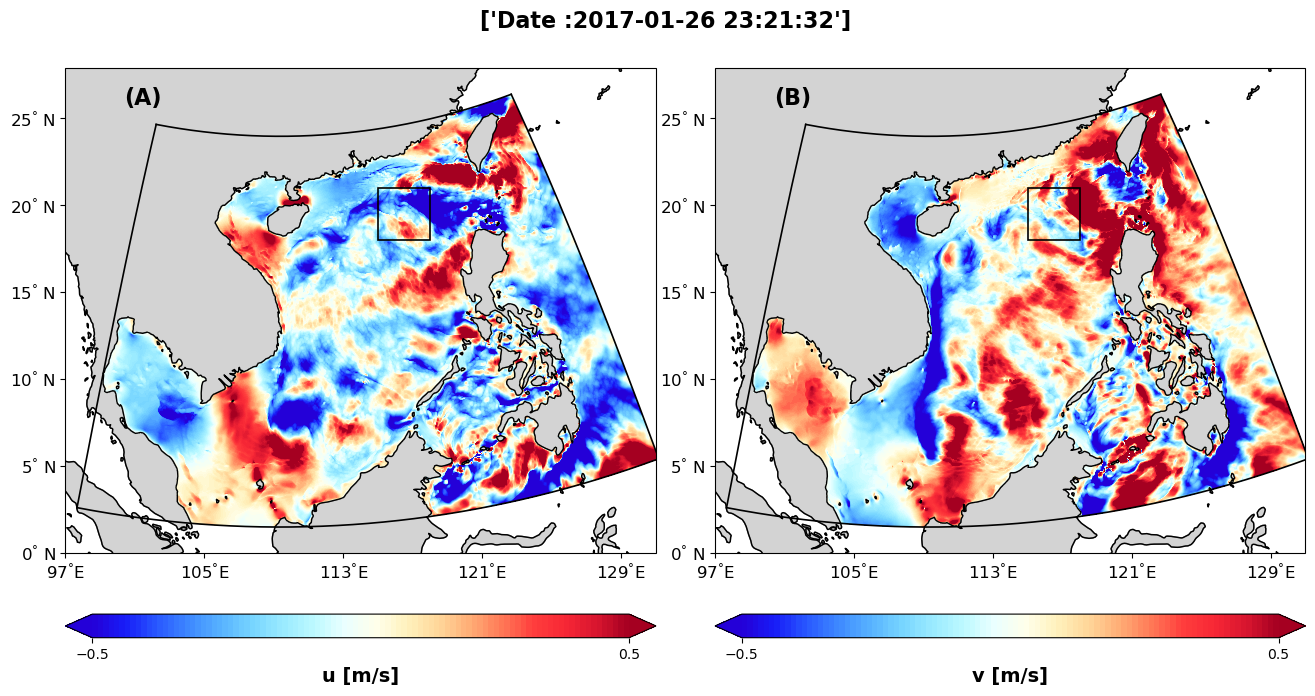

In [20]:
plt.close()
dot=5
mask = u1 == 0 
lonmin=np.min(np.min(lon))
lonmax=np.max(np.max(lon))
latmin=np.min(np.min(lat))
latmax=np.max(np.max(lat))

lonmin=97
lonmax=131
latmin=0
latmax=27
# plt.subplot(2,2,1)
# X,Y=X/2e3,Y/2e3
fig2, ax2 = plt.subplots(1, 2, figsize=(16, 8),subplot_kw={'projection': ccrs.PlateCarree()})

# u
#ax2[0,0].contourf(lon, lat, mask, levels=[0, 1], colors=[(0.7,0.7,0.7)], extend='both', alpha=1)
cs1=ax2[0].contourf(lon,lat,u1,np.linspace(-0.5,0.5,100),vmin=-0.5,vmax=0.5,extend='both',cmap=cbar)
colorbar1=plt.colorbar(cs1, orientation='horizontal', pad=0.1, fraction=0.045, aspect=25)
colorbar1.set_ticks([-0.5,0.5])
colorbar1.set_label('u [m/s]',fontsize=14,fontweight='bold')  # 这里假设单位是度
rect = patches.Rectangle((115, 18), 3, 3, linewidth=1.2, edgecolor='black', facecolor='none', linestyle='-')
ax2[0].add_patch(rect)

ax2[0].coastlines(resolution='50m') 
ax2[0].add_feature(cfeature.LAND, edgecolor='gray', facecolor='lightgray')  # 灰色陆地
ax2[0].set_extent([lonmin,lonmax,latmin,latmax])

ax2[0].set_xticks(np.array((97,105,113,121,129)))  # 设置 x 轴刻度
ax2[0].set_yticks(np.array((0,5,10,15,20,25)))  # 设置 y 轴刻度
ax2[0].xaxis.set_tick_params(labelsize=10)  # 设置 x 轴刻度字体大小
ax2[0].yaxis.set_tick_params(labelsize=10)  # 设置 y 轴刻度字体大小

ax2[0].set_yticklabels([f"${y}^{{\\degree}}$ N" for y in [0, 5, 10, 15, 20, 25]])
ax2[0].set_xticklabels([f"${x}^{{\\degree}}$E" for x in [97, 105, 113, 121, 129]])
ax2[0].text(0.10, 0.96, '(A)', transform=ax2[0].transAxes, fontsize=16, fontweight='bold', va='top')
ax2[0].tick_params(axis='both', which='major', labelsize=12)

# 
ax2[0].plot(lon[0,:],lat[0,:],linewidth=1.2,color='black')
ax2[0].plot(lon[:,0],lat[:,0],linewidth=1.2,color='black')
ax2[0].plot(lon[-1,:],lat[-1,:],linewidth=1.2,color='black')
ax2[0].plot(lon[:,-1],lat[:,-1],linewidth=1.2,color='black')


## v
cs2=ax2[1].contourf(lon,lat,v1,np.linspace(-0.5,0.5,100),vmin=-0.5,vmax=0.5,extend='both',cmap=cbar)
colorbar2=plt.colorbar(cs2, orientation='horizontal', pad=0.1, fraction=0.045, aspect=25)
colorbar2.set_ticks([-0.5,0.5])
colorbar2.set_label('v [m/s]',fontsize=14,fontweight='bold')  # 这里假设单位是度
rect = patches.Rectangle((115, 18), 3, 3, linewidth=1.2, edgecolor='black', facecolor='none', linestyle='-')
ax2[1].add_patch(rect)

ax2[1].coastlines(resolution='50m') 
ax2[1].add_feature(cfeature.LAND, edgecolor='gray', facecolor='lightgray')  # 灰色陆地
ax2[1].set_extent([lonmin,lonmax,latmin,latmax])

ax2[1].set_xticks(np.array((97,105,113,121,129)))  # 设置 x 轴刻度
ax2[1].set_yticks(np.array((0,5,10,15,20,25)))  # 设置 y 轴刻度
ax2[1].xaxis.set_tick_params(labelsize=10)  # 设置 x 轴刻度字体大小
ax2[1].yaxis.set_tick_params(labelsize=10)  # 设置 y 轴刻度字体大小

ax2[1].set_yticklabels([f"${y}^{{\\degree}}$ N" for y in [0, 5, 10, 15, 20, 25]])
ax2[1].set_xticklabels([f"${x}^{{\\degree}}$E" for x in [97, 105, 113, 121, 129]])
ax2[1].text(0.10, 0.96, '(B)', transform=ax2[1].transAxes, fontsize=16, fontweight='bold', va='top')
ax2[1].tick_params(axis='both', which='major', labelsize=12)

# 
ax2[1].plot(lon[0,:],lat[0,:],linewidth=1.2,color='black')
ax2[1].plot(lon[:,0],lat[:,0],linewidth=1.2,color='black')
ax2[1].plot(lon[-1,:],lat[-1,:],linewidth=1.2,color='black')
ax2[1].plot(lon[:,-1],lat[:,-1],linewidth=1.2,color='black')

plt.subplots_adjust(wspace=0.1)  # 设置水平和垂直间距为 0.2，值越小，间距越小
plt.suptitle(['Date :'+T11[0]],fontsize=16,fontweight='bold',y=0.90)

#plt.savefig('/meddy/simingzhang/Analysis/result/Model_snapshot.png', dpi=300, bbox_inches='tight')
plt.show()


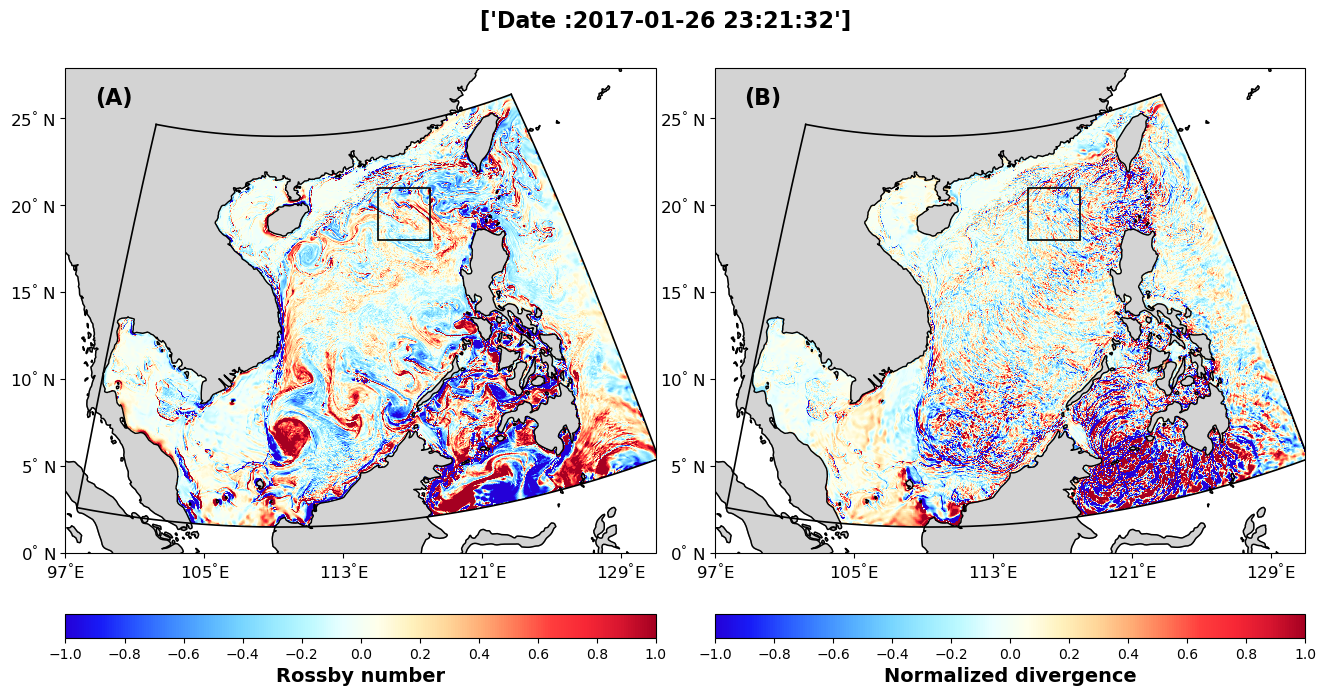

In [128]:
plt.close()
dot=5
mask = u1 == 0 
lonmin=np.min(np.min(lon))
lonmax=np.max(np.max(lon))
latmin=np.min(np.min(lat))
latmax=np.max(np.max(lat))

div[np.isnan(u1)]=np.nan

lonmin=97
lonmax=131
latmin=0
latmax=27
# plt.subplot(2,2,1)
# X,Y=X/2e3,Y/2e3
fig2, ax2 = plt.subplots(1, 2, figsize=(16, 8),subplot_kw={'projection': ccrs.PlateCarree()})

# u
#ax2[0,0].contourf(lon, lat, mask, levels=[0, 1], colors=[(0.7,0.7,0.7)], extend='both', alpha=1)
#cs1=ax2[0].pcolor(lon,lat,vor/f,np.linspace(-1,1,100),vmin=-1,vmax=1,extend='both',cmap=cm.balance)
cs1=ax2[0].pcolormesh(lon,lat,vor/f, shading='auto', cmap=cbar,vmin=-1,vmax=1)  
colorbar1=plt.colorbar(cs1, orientation='horizontal', pad=0.1, fraction=0.045, aspect=25)
colorbar1.set_ticks([-1,-0.8,-0.6,-0.4,-0.2,0,0.2,0.4,0.6,0.8,1])
colorbar1.set_label('Rossby number',fontsize=14,fontweight='bold')  # 这里假设单位是度
rect = patches.Rectangle((115, 18), 3, 3, linewidth=1.2, edgecolor='black', facecolor='none', linestyle='-')
ax2[0].add_patch(rect)


ax2[0].coastlines(resolution='50m') 
ax2[0].add_feature(cfeature.LAND, edgecolor='gray', facecolor='lightgray')  # 灰色陆地
ax2[0].set_extent([lonmin,lonmax,latmin,latmax])

ax2[0].set_xticks(np.array((97,105,113,121,129)))  # 设置 x 轴刻度
ax2[0].set_yticks(np.array((0,5,10,15,20,25)))  # 设置 y 轴刻度
ax2[0].xaxis.set_tick_params(labelsize=10)  # 设置 x 轴刻度字体大小
ax2[0].yaxis.set_tick_params(labelsize=10)  # 设置 y 轴刻度字体大小

ax2[0].set_yticklabels([f"${y}^{{\\degree}}$ N" for y in [0, 5, 10, 15, 20, 25]])
ax2[0].set_xticklabels([f"${x}^{{\\degree}}$E" for x in [97, 105, 113, 121, 129]])
ax2[0].text(0.05, 0.96, '(A)', transform=ax2[0].transAxes, fontsize=16, fontweight='bold', va='top')
ax2[0].tick_params(axis='both', which='major', labelsize=12)

# 
ax2[0].plot(lon[0,:],lat[0,:],linewidth=1.2,color='black')
ax2[0].plot(lon[:,0],lat[:,0],linewidth=1.2,color='black')
ax2[0].plot(lon[-1,:],lat[-1,:],linewidth=1.2,color='black')
ax2[0].plot(lon[:,-1],lat[:,-1],linewidth=1.2,color='black')


## v
#cs2=ax2[1].contourf(lon,lat,div/f,np.linspace(-1,1,100),vmin=-1,vmax=1,extend='both',cmap=cbar)
cs2=ax2[1].pcolormesh(lon,lat,div/f, shading='auto', cmap=cbar,vmin=-1,vmax=1)  
colorbar2=plt.colorbar(cs2, orientation='horizontal', pad=0.1, fraction=0.045, aspect=25)
colorbar2.set_ticks([-1,-0.8,-0.6,-0.4,-0.2,0,0.2,0.4,0.6,0.8,1])
colorbar2.set_label('Normalized divergence',fontsize=14,fontweight='bold')  # 这里假设单位是度
rect = patches.Rectangle((115, 18), 3, 3, linewidth=1.2, edgecolor='black', facecolor='none', linestyle='-')
ax2[1].add_patch(rect)

ax2[1].coastlines(resolution='50m') 
ax2[1].add_feature(cfeature.LAND, edgecolor='gray', facecolor='lightgray')  # 灰色陆地
ax2[1].set_extent([lonmin,lonmax,latmin,latmax])

ax2[1].set_xticks(np.array((97,105,113,121,129)))  # 设置 x 轴刻度
ax2[1].set_yticks(np.array((0,5,10,15,20,25)))  # 设置 y 轴刻度
ax2[1].xaxis.set_tick_params(labelsize=10)  # 设置 x 轴刻度字体大小
ax2[1].yaxis.set_tick_params(labelsize=10)  # 设置 y 轴刻度字体大小

ax2[1].set_yticklabels([f"${y}^{{\\degree}}$ N" for y in [0, 5, 10, 15, 20, 25]])
ax2[1].set_xticklabels([f"${x}^{{\\degree}}$E" for x in [97, 105, 113, 121, 129]])
ax2[1].text(0.05, 0.96, '(B)', transform=ax2[1].transAxes, fontsize=16, fontweight='bold', va='top')
ax2[1].tick_params(axis='both', which='major', labelsize=12)

# 
ax2[1].plot(lon[0,:],lat[0,:],linewidth=1.2,color='black')
ax2[1].plot(lon[:,0],lat[:,0],linewidth=1.2,color='black')
ax2[1].plot(lon[-1,:],lat[-1,:],linewidth=1.2,color='black')
ax2[1].plot(lon[:,-1],lat[:,-1],linewidth=1.2,color='black')

plt.subplots_adjust(wspace=0.1)  # 设置水平和垂直间距为 0.2，值越小，间距越小
plt.suptitle(['Date :'+T11[0]],fontsize=16,fontweight='bold',y=0.90)

#plt.savefig('/meddy/simingzhang/Analysis/result/Model_snapshot2.png', dpi=300, bbox_inches='tight')
plt.show()


In [27]:
maskr=ds['mask_rho'].values


In [31]:
print(maskr[-1,:])

[0. 0. 0. ... 1. 1. 1.]


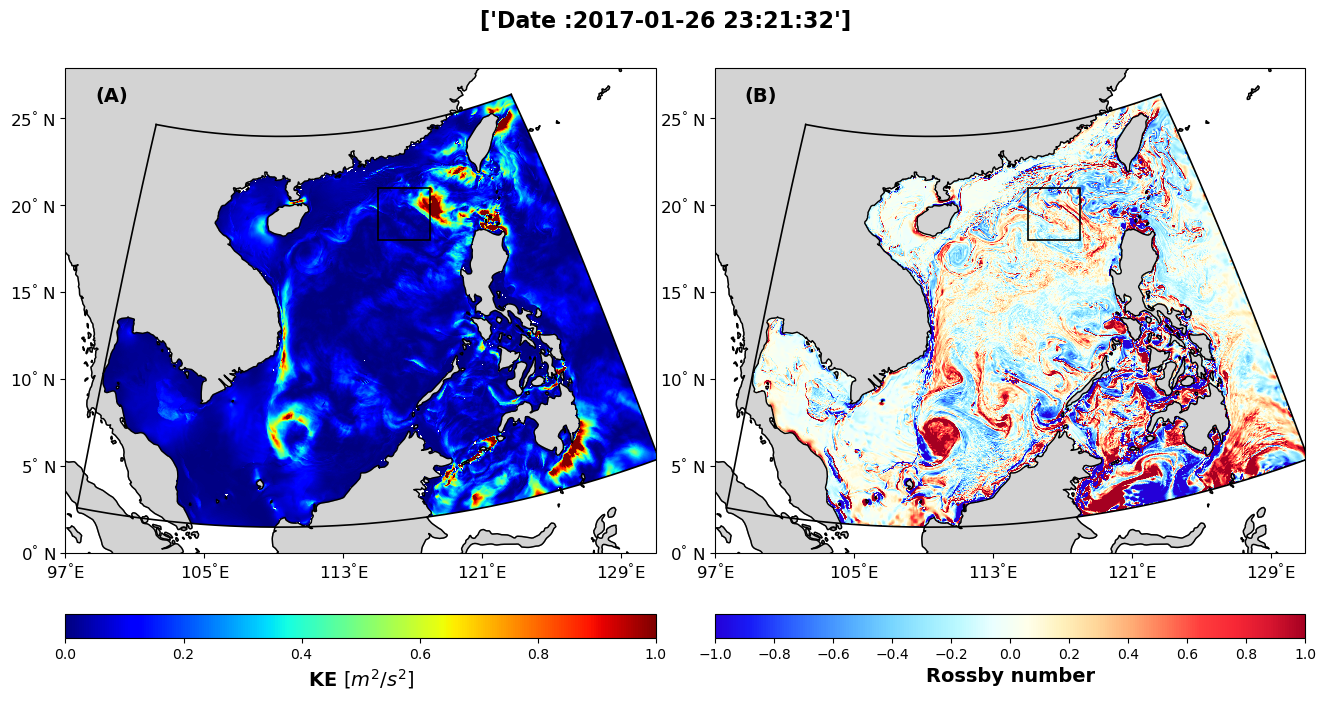

In [130]:
plt.close()
dot=5
mask = u1 == 0 
lonmin=np.min(np.min(lon))
lonmax=np.max(np.max(lon))
latmin=np.min(np.min(lat))
latmax=np.max(np.max(lat))

vor[np.isnan(u1)]=np.nan

lonmin=97
lonmax=131
latmin=0
latmax=27
# plt.subplot(2,2,1)
# X,Y=X/2e3,Y/2e3
fig2, ax2 = plt.subplots(1, 2, figsize=(16, 8),subplot_kw={'projection': ccrs.PlateCarree()})

# u
#ax2[0,0].contourf(lon, lat, mask, levels=[0, 1], colors=[(0.7,0.7,0.7)], extend='both', alpha=1)
#cs1=ax2[0].contourf(lon,lat,0.5*(u1**2+v1**2),np.linspace(0,1,100),vmin=0,vmax=1,extend='both',cmap=plt.cm.jet)
cs1=ax2[0].pcolormesh(lon,lat,0.5*(u1**2+v1**2),vmin=0,vmax=1,cmap=plt.cm.jet)

colorbar1=plt.colorbar(cs1, orientation='horizontal', pad=0.1, fraction=0.045, aspect=25)
colorbar1.set_ticks([0,0.2,0.4,0.6,0.8,1])
colorbar1.set_label('KE $[m^{2}/s^{2}]$',fontsize=14,fontweight='bold')  # 这里假设单位是度
rect = patches.Rectangle((115, 18), 3, 3, linewidth=1.2, edgecolor='black', facecolor='none', linestyle='-')
ax2[0].add_patch(rect)

ax2[0].coastlines(resolution='50m') 
ax2[0].add_feature(cfeature.LAND, edgecolor='gray', facecolor='lightgray')  # 灰色陆地
ax2[0].set_extent([lonmin,lonmax,latmin,latmax])

ax2[0].set_xticks(np.array((97,105,113,121,129)))  # 设置 x 轴刻度
ax2[0].set_yticks(np.array((0,5,10,15,20,25)))  # 设置 y 轴刻度
ax2[0].xaxis.set_tick_params(labelsize=10)  # 设置 x 轴刻度字体大小
ax2[0].yaxis.set_tick_params(labelsize=10)  # 设置 y 轴刻度字体大小

ax2[0].set_yticklabels([f"${y}^{{\\degree}}$ N" for y in [0, 5, 10, 15, 20, 25]])
ax2[0].set_xticklabels([f"${x}^{{\\degree}}$E" for x in [97, 105, 113, 121, 129]])
ax2[0].text(0.05, 0.96, '(A)', transform=ax2[0].transAxes, fontsize=14, fontweight='bold', va='top')
ax2[0].tick_params(axis='both', which='major', labelsize=12)

# 
ax2[0].plot(lon[0,:],lat[0,:],linewidth=1.2,color='black')
ax2[0].plot(lon[:,0],lat[:,0],linewidth=1.2,color='black')
ax2[0].plot(lon[-1,:],lat[-1,:],linewidth=1.2,color='black')
ax2[0].plot(lon[:,-1],lat[:,-1],linewidth=1.2,color='black')


## v
vor[np.isnan(u1)]=np.nan
#cs2=ax2[1].contourf(lon,lat,vor/f,np.linspace(-1,1,100),vmin=-1,vmax=1,extend='both',cmap=cbar)
cs2=ax2[1].pcolormesh(lon,lat,vor/f, shading='auto', cmap=cbar,vmin=-1,vmax=1)  # 使用 'auto' 来自动平滑插值

colorbar2=plt.colorbar(cs2, orientation='horizontal', pad=0.1, fraction=0.045, aspect=25)
colorbar2.set_ticks([-1,-0.8,-0.6,-0.4,-0.2,0,0.2,0.4,0.6,0.8,1])
colorbar2.set_label('Rossby number',fontsize=14,fontweight='bold')  # 这里假设单位是度
rect = patches.Rectangle((115, 18), 3, 3, linewidth=1.2, edgecolor='black', facecolor='none', linestyle='-')
ax2[1].add_patch(rect)

ax2[1].coastlines(resolution='50m') 
ax2[1].add_feature(cfeature.LAND, edgecolor='gray', facecolor='lightgray')  # ax2[0].set_ylabel('lattiude $[\degree]$',fontsize=14,fontweight='bold')


ax2[1].set_extent([lonmin,lonmax,latmin,latmax])

ax2[1].set_xticks(np.array((97,105,113,121,129)))  # 设置 x 轴刻度
ax2[1].set_yticks(np.array((0,5,10,15,20,25)))  # 设置 y 轴刻度
ax2[1].xaxis.set_tick_params(labelsize=10)  # 设置 x 轴刻度字体大小
ax2[1].yaxis.set_tick_params(labelsize=10)  # 设置 y 轴刻度字体大小
ax2[1].set_yticklabels([f"${y}^{{\\degree}}$ N" for y in [0, 5, 10, 15, 20, 25]])
ax2[1].set_xticklabels([f"${x}^{{\\degree}}$E" for x in [97, 105, 113, 121, 129]])

ax2[1].text(0.05, 0.96, '(B)', transform=ax2[1].transAxes, fontsize=14, fontweight='bold', va='top')
ax2[1].tick_params(axis='both', which='major', labelsize=12)

# 
ax2[1].plot(lon[0,:],lat[0,:],linewidth=1.2,color='black')
ax2[1].plot(lon[:,0],lat[:,0],linewidth=1.2,color='black')
ax2[1].plot(lon[-1,:],lat[-1,:],linewidth=1.2,color='black')
ax2[1].plot(lon[:,-1],lat[:,-1],linewidth=1.2,color='black')

plt.subplots_adjust(wspace=0.1)  # 设置水平和垂直间距为 0.2，值越小，间距越小
plt.suptitle(['Date :'+T11[0]],fontsize=16,fontweight='bold',y=0.90)

plt.savefig('/meddy/simingzhang/Analysis/result/Model_snapshot3.png', dpi=300, bbox_inches='tight')
plt.show()


In [21]:
mask

array([[False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       ...,
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False]])

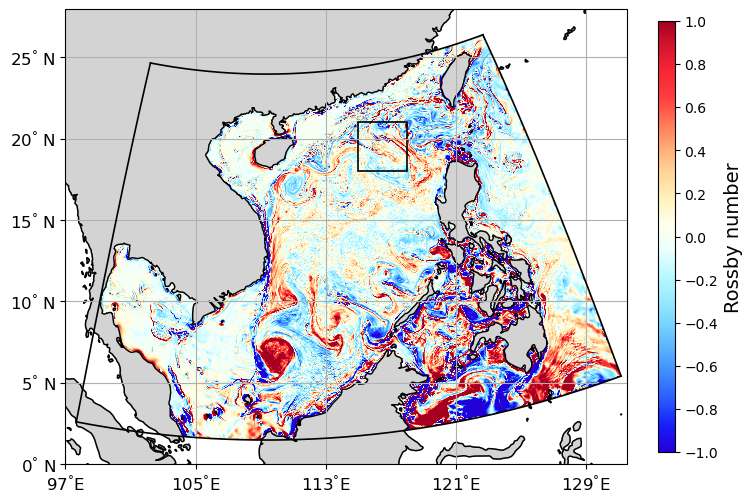

In [137]:
plt.close()
dot=5
mask = u1 == 0 
lonmin=np.min(np.min(lon))
lonmax=np.max(np.max(lon))
latmin=np.min(np.min(lat))
latmax=np.max(np.max(lat))

vor[u1==np.nan]=np.nan

lonmin=97
lonmax=131.5
latmin=0
latmax=27
# plt.subplot(2,2,1)
# X,Y=X/2e3,Y/2e3
fig2, ax2 = plt.subplots(1, 1, figsize=(8, 8),subplot_kw={'projection': ccrs.PlateCarree()})

vor[np.isnan(u1)]=np.nan
cs2=ax2.pcolormesh(lon,lat,vor/f, shading='auto', cmap=cbar,vmin=-1,vmax=1)  # 使用 'auto' 来自动平滑插值
colorbar2=plt.colorbar(cs2, pad=0.05, fraction=0.045, aspect=25,shrink=0.7)
colorbar2.set_ticks([-1,-0.8,-0.6,-0.4,-0.2,0,0.2,0.4,0.6,0.8,1])
colorbar2.set_label('Rossby number',fontsize=14)  # 这里假设单位是度

rect = patches.Rectangle((115, 18), 3, 3, linewidth=1.2, edgecolor='black', facecolor='none', linestyle='-')
ax2.add_patch(rect)

ax2.coastlines(resolution='50m') 
ax2.add_feature(cfeature.LAND, edgecolor='gray', facecolor='lightgray')  # 灰色陆地
ax2.set_extent([lonmin,lonmax,latmin,latmax])

ax2.set_xticks(np.array((97,105,113,121,129)))  # 设置 x 轴刻度
ax2.set_yticks(np.array((0,5,10,15,20,25)))  # 设置 y 轴刻度
ax2.set_yticklabels([f"${y}^{{\\degree}}$ N" for y in [0, 5, 10, 15, 20, 25]])
ax2.set_xticklabels([f"${x}^{{\\degree}}$E" for x in [97, 105, 113, 121, 129]])

ax2.xaxis.set_tick_params(labelsize=10)  # 设置 x 轴刻度字体大小
ax2.yaxis.set_tick_params(labelsize=10)  # 设置 y 轴刻度字体大小


#ax2.text(0.05, 0.96, '(A)', transform=ax2.transAxes, fontsize=16, fontweight='bold', va='top')
ax2.tick_params(axis='both', which='major', labelsize=12)

# 
ax2.plot(lon[0,:],lat[0,:],linewidth=1.2,color='black')
ax2.plot(lon[:,0],lat[:,0],linewidth=1.2,color='black')
ax2.plot(lon[-1,:],lat[-1,:],linewidth=1.2,color='black')
ax2.plot(lon[:,-1],lat[:,-1],linewidth=1.2,color='black')
ax2.grid(True)

#plt.subplots_adjust(wspace=0.1)  # 设置水平和垂直间距为 0.2，值越小，间距越小
#plt.suptitle(['Date :'+T11[0]],fontsize=16,fontweight='bold',y=0.90)

plt.savefig('/meddy/simingzhang/Analysis/result/Model_snapshot4.png', dpi=600, bbox_inches='tight')
plt.show()


In [100]:
aa=vor/f
bb=div/f
aa[np.isnan(aa)]=0
bb[np.isnan(bb)]=0
np.max(aa),np.max(bb)

(74.11895098855472, 36.76119988912726)

In [101]:
aa

array([[ 0.        ,  0.        ,  0.        , ...,  1.03615911,
         0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        , ...,  1.03253992,
         0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        , ...,  0.8286759 ,
         0.        ,  0.        ],
       ...,
       [ 0.        ,  0.        ,  0.        , ..., -1.06375195,
         0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ]])